<a href="https://colab.research.google.com/github/kosar-am/finance-prediction-rnn/blob/main/notebooks/03_simple_rnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Stock Price Prediction using RNN, LSTM, and GRU

## 03 — Simple RNN Model

In this notebook, a Simple Recurrent Neural Network (RNN) model is built and trained to predict Google stock prices using the preprocessed sequential dataset.

### Objectives

- Load and preprocess the dataset
- Build a Simple RNN model
- Train the model
- Evaluate the model
- Visualize the training process
- Predict stock prices on the test set

## 📚 Import Required Libraries

In [28]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,SimpleRNN, Dense




In [13]:
RESULTS_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026/results"


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

In [4]:
from src.preprocessing import prepare_data

print("✅ Preprocessing module imported successfully.")

✅ Preprocessing module imported successfully.


## Data Preparation

In this section, the preprocessed sequential dataset is loaded using the reusable `prepare_data()` function from the `src.preprocessing` module.

The data is split into training and testing sets and reshaped into the three-dimensional format required by recurrent neural networks:

`(samples, time steps, features)`

In [5]:
# Load preprocessed data

X_train, X_test, y_train, y_test, scaler = prepare_data()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

[*********************100%***********************]  1 of 1 completed

X_train shape: (2152, 60, 1)
X_test shape : (493, 60, 1)
y_train shape: (2152, 1)
y_test shape : (493, 1)


## Building the Simple RNN Model

In [8]:


model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN(units=50, activation="tanh"),
    Dense(1)
])

## Compiling the Model

In [9]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

## Training the Model

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0076 - val_loss: 0.1213
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0416e-04 - val_loss: 0.1023
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3.7318e-04 - val_loss: 0.0940
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.6021e-04 - val_loss: 0.0894
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4096e-04 - val_loss: 0.0798
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.2730e-04 - val_loss: 0.0774
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9521e-04 - val_loss: 0.0730
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.3545e-04 - val_loss: 0.0679
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8927e-04 - val_loss: 0.0672
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.7550e-04 - val_loss: 0.0628
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0737e-04 - val_loss: 0.0631
Epoch 12/20
68/68 ━━━━━

## Visualizing the Results

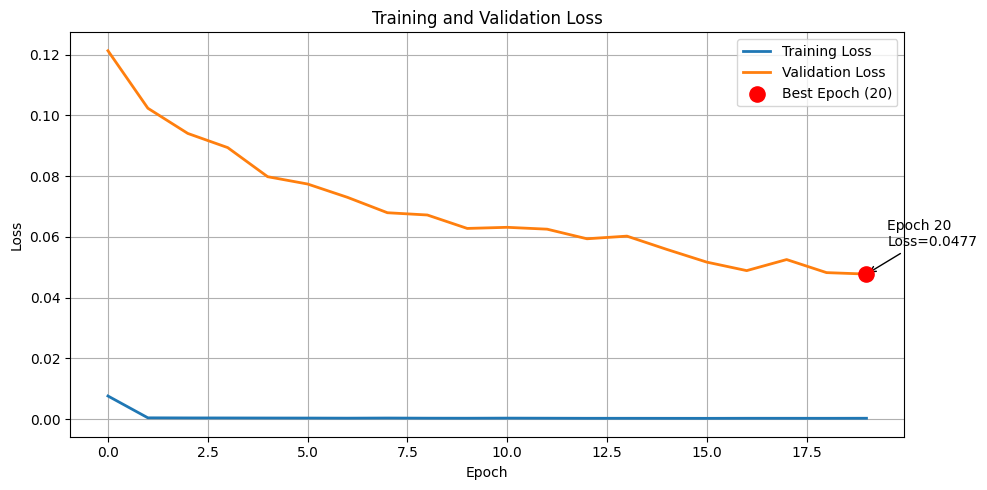

Best Epoch: 20
Lowest Validation Loss: 0.047731


In [16]:


# Find the best epoch based on the lowest validation loss
best_epoch = np.argmin(history.history["val_loss"])
best_val_loss = history.history["val_loss"][best_epoch]

plt.figure(figsize=(10, 5))

# Plot training and validation loss
plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

# Highlight the best epoch
plt.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=120,
    zorder=5,
    label=f"Best Epoch ({best_epoch + 1})"
)

plt.annotate(
    f"Epoch {best_epoch + 1}\nLoss={best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(15, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/rnn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best Epoch: {best_epoch + 1}")
print(f"Lowest Validation Loss: {best_val_loss:.6f}")

### Analysis

- The validation loss consistently decreased throughout the training process, indicating that the model successfully learned meaningful patterns from the data.
- The lowest validation loss (0.0477) was achieved at **Epoch 20**, which was selected as the best training epoch.
- No significant increase in validation loss was observed, suggesting that the model did not exhibit obvious overfitting within 20 epochs.
- Although the training loss rapidly approached zero, a noticeable gap remained between the training and validation losses. This indicates that the model fits the training data better than the unseen test data, leaving room for improved generalization.

## Evaluating the Model

In [22]:
# Predict on the test set
y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [23]:
# Convert predictions back to the original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

In [24]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 16.0971
RMSE: 27.3194
R²  : 0.6148


### Actual vs Predicted Stock Prices

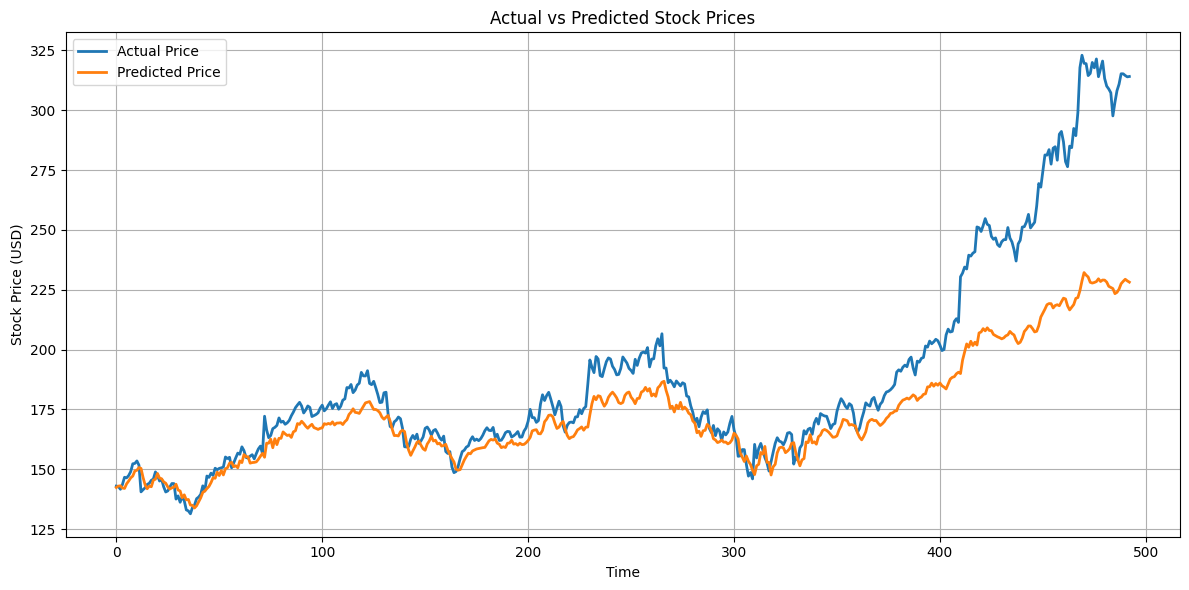

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    y_pred_actual,
    label="Predicted Price",
    linewidth=2
)

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/rnn_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

- The RNN model successfully captured the overall trend of the stock prices, and the predicted values generally followed the movement of the actual prices.
- The predictions were relatively accurate during periods of moderate price fluctuations.
- However, the model struggled to capture the sharp upward movement observed near the end of the test period, leading to an underestimation of the actual stock prices.
- Overall, the model learned the long-term trend reasonably well, but its performance decreased during periods of rapid market growth and high volatility.

### Residual Plot

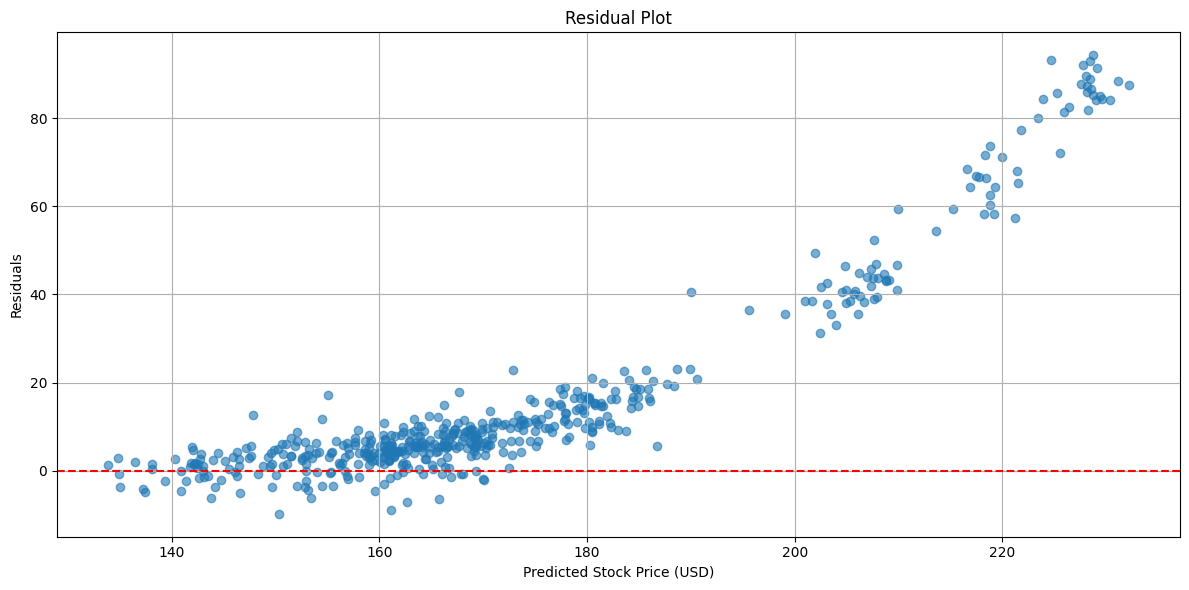

In [26]:
# Calculate residuals
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(12, 6))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Stock Price (USD)")
plt.ylabel("Residuals")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/rnn_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

- Ideally, residuals should be randomly distributed around the zero line without any visible pattern.
- In this plot, the residuals increase as the predicted stock price increases, indicating a systematic error rather than random noise.
- The positive residuals at higher predicted prices suggest that the RNN model tends to underestimate the actual stock prices during periods of strong market growth.
- Overall, the residual plot indicates that the model captures the general trend but struggles to accurately predict large price movements and high-value observations.

In [29]:


metrics = pd.DataFrame({
    "Model": ["RNN"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    f"{RESULTS_PATH}/rnn_metrics.csv",
    index=False
)

metrics

,Model,MAE,RMSE,R2
0,RNN,16.097142,27.31938,0.614765
